In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df_comments=pd.read_parquet('df_comments_sentiment_embeddings_bucket.parquet')
df_videos=pd.read_parquet('df_videos_text_sentiment_embeddings.parquet')
df_tesla=pd.read_parquet('tesla_financial_data.parquet')

In [30]:
# only comments has the exact date ath whih videos got published so I am going to extract them
vid_id=df_comments[['video_id', 'video_url', 'video_published_at']].drop_duplicates(subset=['video_id', 'video_url'])
df_videos_merged=vid_id.merge(df_videos, how='inner',left_on='video_url', right_on="Link")
df_videos_merged.reset_index(inplace=True)
df_videos_merged.drop(['index', 'Unnamed: 0', 'Date'], axis=1, inplace=True)
    

In [31]:
#print(df_comments.info())
#print(df_videos.info())
print(df_tesla.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype                     
---  ------               --------------  -----                     
 0   Stock_Date           543 non-null    datetime64[ns, US/Eastern]
 1   Closing Price($)     543 non-null    float64                   
 2   relative difference  542 non-null    float64                   
dtypes: datetime64[ns, US/Eastern](1), float64(2)
memory usage: 12.9 KB
None


In [32]:
#merging video ids on the same date, it didn't get so well so I will use the day notthe exact hours

df_comments.rename(columns={'YYYY_MM_DD':"comment_published_at_YMD"}, inplace=True)
df_videos_merged['video_published_at_YMD']=df_videos_merged['video_published_at'].dt.strftime('%Y-%m-%d')


In [33]:
#and now we do the merge on videos and comments that correspond to the same day, for comments we take the median day
df_comments_videos=df_comments.merge(df_videos_merged, how='left',left_on='comment_published_at_YMD', right_on="video_published_at_YMD")

In [34]:
df_comments_videos.columns

Index(['Unnamed: 0', 'comment_text', 'comment_likes', 'comment_published_at',
       'video_title', 'video_published_at_x', 'video_url_x', 'month-year',
       'comment_lang', 'comment_sentiment', 'comment_text_normalized',
       'video_id_x', 'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_sentiment_agg', 'comment_embeddings_agg',
       'video_id_y', 'video_url_y', 'video_published_at_y', 'Link',
       'video_text', 'sentiment_tensor', 'video_text_normalized',
       'videos_text_embeddings', 'video_published_at_YMD'],
      dtype='object')

In [35]:
#Market Vector as in Khanna et al 2025 Source: https://arxiv.org/pdf/2508.13327 No pca required for modelling
#Appart from their work I have a model of 256emmbeddings per row not 768

df_modelling=df_comments_videos[["video_id_x", 'comment_published_at_YMD', "number_of_comments_at_date", 'comment_likes_agg', 'comment_embeddings_agg','comment_sentiment_agg','sentiment_tensor', 'videos_text_embeddings']]

In [36]:
import pytz
from datetime import datetime

# get timezone
et = pytz.timezone("US/Eastern")


#converting date columns to simple date YYYY-MM-DD
df_modelling['comment_published_at_YMD']=pd.to_datetime(df_modelling['comment_published_at_YMD'],utc=True).dt.tz_convert(et)
df_tesla['Stock_Date']=pd.to_datetime(df_tesla['Stock_Date'], utc=True).dt.tz_convert(et)
df_tesla.sort_values("Stock_Date", inplace=True)

df_modelling=df_modelling.sort_values('comment_published_at_YMD')

/var/folders/vq/lk7nh_yn6tb1b_v3zw2jkq1c0000gp/T/ipykernel_63091/94177257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelling['comment_published_at_YMD']=pd.to_datetime(df_modelling['comment_published_at_YMD'],utc=True).dt.tz_convert(et)


In [37]:
#merging the financial data with merge as of otherwise the data is lost because 
# lots of comments are written on weekends when stock markets are closed
# Khanna et al merges yahoo financce with how=inner 

df_modelling=pd.merge_asof(df_tesla,df_modelling, direction='backward',left_on='Stock_Date', right_on='comment_published_at_YMD')

In [38]:
df_modelling

,Stock_Date,Closing Price($),relative difference,video_id_x,comment_published_at_YMD,number_of_comments_at_date,comment_likes_agg,comment_embeddings_agg,comment_sentiment_agg,sentiment_tensor,videos_text_embeddings
0,2023-09-01 00:00:00-04:00,245.009995,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-09-05 00:00:00-04:00,256.489990,0.046855,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-09-06 00:00:00-04:00,251.919998,-0.017817,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-07 00:00:00-04:00,251.490005,-0.001707,44.0,2023-09-06 20:00:00-04:00,16.0,66.0,"[-0.0013847351, -0.030739784, -0.009982109, -0...",-0.051671,NaN,NaN
4,2023-09-08 00:00:00-04:00,248.500000,-0.011889,44.0,2023-09-07 20:00:00-04:00,7.0,23.0,"[0.0008370536, -0.014247349, -0.01007516, -0.0...",-0.204929,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
538,2025-10-24 00:00:00-04:00,433.720001,-0.033988,66.0,2025-10-23 20:00:00-04:00,5.0,0.0,"[0.012046814, -0.024713134, -0.010980224, 0.03...",0.471151,NaN,NaN
539,2025-10-27 00:00:00-04:00,452.420013,0.043115,32.0,2025-10-26 20:00:00-04:00,2.0,0.0,"[0.019599915, 0.0065307617, -0.011688232, 0.03...",0.083959,NaN,NaN
540,2025-10-28 00:00:00-04:00,460.549988,0.017970,20.0,2025-10-27 20:00:00-04:00,3.0,1.0,"[0.007751465, -0.010945638, -0.010498047, 0.02...",0.461608,NaN,NaN
541,2025-10-29 00:00:00-04:00,461.510010,0.002085,74.0,2025-10-28 20:00:00-04:00,3.0,0.0,"[-0.0009358724, -0.009348552, -0.008412679, 0....",0.217439,NaN,NaN


In [39]:
#2. cheknig if every day in the period was a comment on Youtube
#creating dates from the selected period
dates=pd.date_range(start="2023-09-01", end="2025-10-31", freq="D")
dates=pd.DataFrame({"Dates":dates})
dates["Dates"]=dates["Dates"].dt.strftime("%Y-%m-%d")
all_days=pd.merge(dates, df_comments_videos, how="left", left_on="Dates", right_on="comment_published_at_YMD")


Number of all days that fall under analysis:  792
Number of empty comment days 94


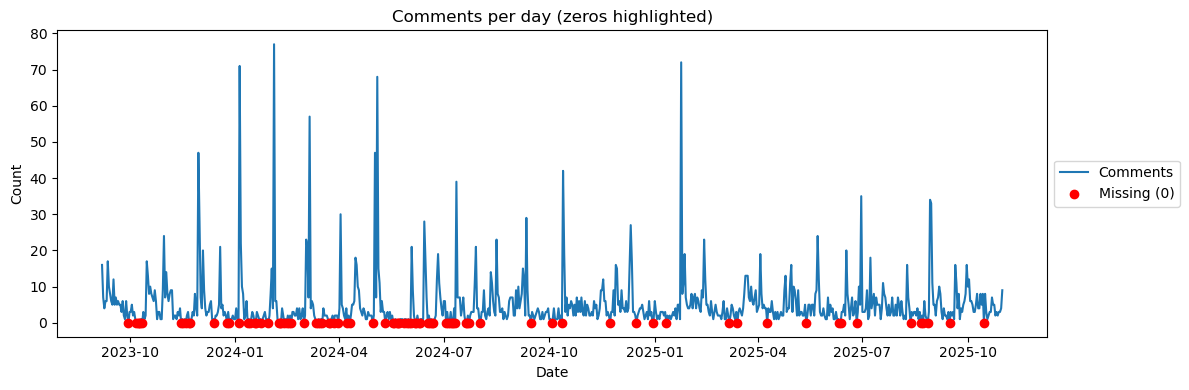

In [40]:
all_days['comment_published_at_YMD']=pd.to_datetime(all_days['comment_published_at_YMD'])

daily_counts = all_days.groupby(all_days["comment_published_at_YMD"].dt.date).size()
daily_counts = daily_counts.asfreq("D", fill_value=0)
print("Number of all days that fall under analysis: ", len(dates["Dates"]))
print("Number of empty comment days" ,all_days['comment_published_at'].isna().sum())
plt.figure(figsize=(12, 4))

# plot line
plt.plot(daily_counts.index, daily_counts.values, label="Comments")

# highlight zeros
zeros = daily_counts[daily_counts == 0]
plt.scatter(zeros.index, zeros.values, color="red", label="Missing (0)", zorder=5)

plt.title("Comments per day (zeros highlighted)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend(frameon=True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig("Frequencyofcomments.png",transparent=True, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [41]:
df_tesla["Stock_Date_YMD"]=df_tesla["Stock_Date"].dt.strftime("%Y-%m-%d")
all_days_1=pd.merge(dates, df_tesla, how="left", left_on="Dates", right_on="Stock_Date_YMD")

print("Number of all days that fall under analysis: ", all_days_1.shape[0])
print("Number of empty tradiong days" ,all_days_1['Stock_Date_YMD'].isna().sum())
all_days_1


Number of all days that fall under analysis:  792
Number of empty tradiong days 249


,Dates,Stock_Date,Closing Price($),relative difference,Stock_Date_YMD
0,2023-09-01,2023-09-01 00:00:00-04:00,245.009995,NaN,2023-09-01
1,2023-09-02,NaT,NaN,NaN,NaN
2,2023-09-03,NaT,NaN,NaN,NaN
3,2023-09-04,NaT,NaN,NaN,NaN
4,2023-09-05,2023-09-05 00:00:00-04:00,256.489990,0.046855,2023-09-05
...,...,...,...,...,...
787,2025-10-27,2025-10-27 00:00:00-04:00,452.420013,0.043115,2025-10-27
788,2025-10-28,2025-10-28 00:00:00-04:00,460.549988,0.017970,2025-10-28
789,2025-10-29,2025-10-29 00:00:00-04:00,461.510010,0.002085,2025-10-29
790,2025-10-30,2025-10-30 00:00:00-04:00,440.100006,-0.046391,2025-10-30


In [42]:
#Missing values due to missing video for the specified date
df_modelling[['sentiment_tensor','videos_text_embeddings']].info()
#inputing 0 for missing values
df_modelling['sentiment_tensor']=df_modelling['sentiment_tensor'].fillna(0)
#inputing (1,256) shape 0 array for embeddings
import numpy as np

zero_vec = np.zeros(256, dtype=np.float32)

mask = df_modelling['videos_text_embeddings'].isna()

df_modelling.loc[mask, 'videos_text_embeddings'] = pd.Series(
    [zero_vec] * mask.sum(),
    index=df_modelling.index[mask]
)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sentiment_tensor        45 non-null     float64
 1   videos_text_embeddings  47 non-null     object 
dtypes: float64(1), object(1)
memory usage: 8.6+ KB


In [43]:
df_modelling["Difference"]=df_modelling["Stock_Date"]-df_modelling['comment_published_at_YMD']

In [44]:
#creating window for videos
df_modelling.sort_values('Stock_Date', inplace=True)
df_modelling['videos_text_embeddings_window']=None
window=5 #window is 5 days

for i in range(len(df_modelling)):
    current_day=df_modelling.loc[i,'Stock_Date']
    window_start=current_day-pd.Timedelta(days=5)
    mask=((df_modelling["Stock_Date"]>=window_start)&(df_modelling["Stock_Date"]<current_day))
    if not mask.any():
        window_embedding=zero_vec = np.zeros(256, dtype=np.float32)
    else:
        embeddings=np.stack(df_modelling.loc[mask, "videos_text_embeddings"])
        window_embedding=np.mean(embeddings, axis=0)
        df_modelling.at[i, "videos_text_embeddings_window"]=np.array(window_embedding)







In [45]:
#creatig target variable, 1- Up, 0- Down
df_modelling['TargetVariable:Up/Down']=df_modelling['relative difference'].apply(lambda x: 1 if x>=0 else 0)

In [46]:
# #scaling
# data_to_normalize=["Closing Price($)", 'relative difference', 'number_of_comments_at_date', 'comment_likes_agg']

# #scaling the numerical values
# from sklearn.preprocessing import StandardScaler
# scale=StandardScaler()
# df_modelling[data_to_normalize]=scale.fit_transform(df_modelling[data_to_normalize])



In [47]:
#drop unwanted columns 
df_modelling.drop(['video_id_x'], axis=1, inplace=True)
df_modelling.columns

Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down'],
      dtype='object')

In [48]:
df_modelling.dropna(inplace=True)
df_modelling.info()


<class 'pandas.core.frame.DataFrame'>
Index: 540 entries, 3 to 542
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype                     
---  ------                         --------------  -----                     
 0   Stock_Date                     540 non-null    datetime64[ns, US/Eastern]
 1   Closing Price($)               540 non-null    float64                   
 2   relative difference            540 non-null    float64                   
 3   comment_published_at_YMD       540 non-null    datetime64[ns, US/Eastern]
 4   number_of_comments_at_date     540 non-null    float64                   
 5   comment_likes_agg              540 non-null    float64                   
 6   comment_embeddings_agg         540 non-null    object                    
 7   comment_sentiment_agg          540 non-null    float64                   
 8   sentiment_tensor               540 non-null    float64                   
 9   videos_text_embeddings    

<Axes: >

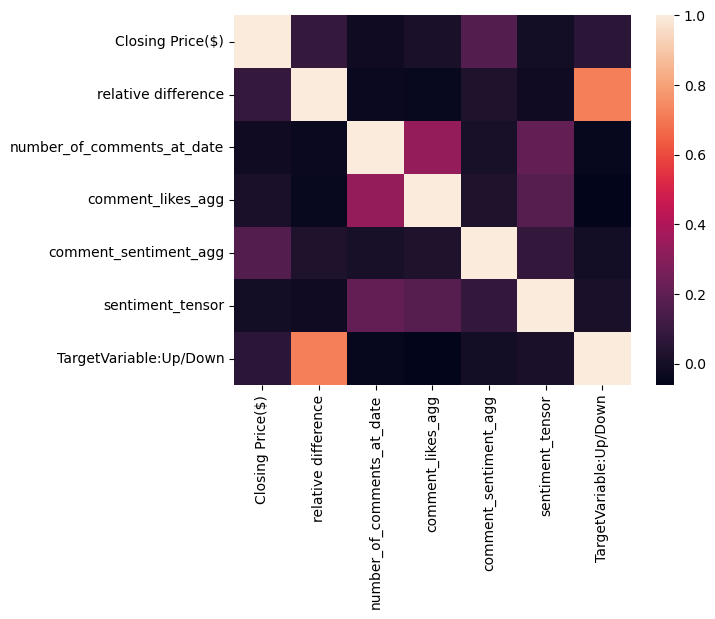

In [49]:
df_heatmap=df_modelling[['Closing Price($)', 'relative difference', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'TargetVariable:Up/Down']].corr()

import seaborn as sns

sns.heatmap(df_heatmap)

#interesting observations:
# the more comments in a time frame the worst the sentiment for both comments and videos
# relative difference  is positively correlated to the target variable, but this is okay it is not multicoliniarity

In [50]:
#keeping the unique dates only
df_modelling=df_modelling.drop_duplicates(subset=['comment_published_at_YMD'])
#shifting collumns to prevent data leakage
lag_columns=['Closing Price($)','relative difference']
for col in lag_columns:
    df_modelling[f"{col} lag1"]=df_modelling[col].shift(1)
#dropping forst row because it has been shifted one row
df_modelling=df_modelling.iloc[1:]

/var/folders/vq/lk7nh_yn6tb1b_v3zw2jkq1c0000gp/T/ipykernel_63091/882215191.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelling[f"{col} lag1"]=df_modelling[col].shift(1)
/var/folders/vq/lk7nh_yn6tb1b_v3zw2jkq1c0000gp/T/ipykernel_63091/882215191.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelling[f"{col} lag1"]=df_modelling[col].shift(1)


In [51]:
# convert to pure calendar dates (remove time)
stock_date = df_modelling["Stock_Date"].dt.date
comment_date = df_modelling["comment_published_at_YMD"].dt.date

# compute difference in days
df_modelling["Calendar_Diff_Days"] = (stock_date - comment_date).apply(lambda x: x.days)
df_modelling[['Stock_Date',"comment_published_at_YMD","Calendar_Diff_Days"]].sort_values("Calendar_Diff_Days",ascending=False)

,Stock_Date,comment_published_at_YMD,Calendar_Diff_Days
193,2024-06-10 00:00:00-04:00,2024-06-07 20:00:00-04:00,3
509,2025-09-15 00:00:00-04:00,2025-09-13 20:00:00-04:00,2
198,2024-06-17 00:00:00-04:00,2024-06-15 20:00:00-04:00,2
149,2024-04-08 00:00:00-04:00,2024-04-06 20:00:00-04:00,2
333,2024-12-30 00:00:00-05:00,2024-12-28 19:00:00-05:00,2
...,...,...,...
194,2024-06-11 00:00:00-04:00,2024-06-10 20:00:00-04:00,1
190,2024-06-05 00:00:00-04:00,2024-06-04 20:00:00-04:00,1
189,2024-06-04 00:00:00-04:00,2024-06-03 20:00:00-04:00,1
188,2024-06-03 00:00:00-04:00,2024-06-02 20:00:00-04:00,1


In [52]:

df_modelling.sort_values("comment_published_at_YMD",inplace=True)
#saving the final dataset
df_modelling.to_parquet("df_modelling.parquet", index=False)